# 01 - Análisis Exploratorio de Datos (EDA)
## Proyecto: Predicción de Abandono (Churn) - AndesLink
**Alumno:** Facundo Zubeldia - Gonzalo Martin Gonzalez Nastovich - Agustin Meza 
**Materia:** Laboratorio de Minería de Datos - ISTEA

## Contexto de negocio
 
AndesLink Servicios Digitales S.A. ofrece planes de suscripción mensual.
El **churn** (abandono) ocurre cuando un cliente cancela voluntariamente su servicio.
 
Anticipar el churn permite activar campañas de retención **antes** de que el cliente se vaya,
reduciendo el costo de adquisición de nuevos usuarios y estabilizando el flujo de caja.
 
### ¿Por qué estas variables predicen churn?
 
| Variable | Hipótesis de negocio |
|---|---|
| `tenure_months` | Clientes nuevos tienen mayor riesgo de fuga (período de prueba) |
| `monthly_charge` | Cargos altos generan más fricción si el cliente no percibe valor |
| `support_tickets` | Muchos tickets = experiencia frustrante = señal de salida |
| `late_payments` | Pagos tardíos indican desenganche o problemas financieros |
| `contract_type` | Contratos mensuales tienen menor compromiso que anuales/bianuales |
| `num_products` | Más productos = más dependencia del servicio = menor churn |
 
### Variable objetivo
- `churn = 1`: el cliente abandonó el servicio
- `churn = 0`: el cliente continúa activo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from pathlib import Path
##
mlflow.set_experiment("AndesLink_Churn_Prediction")
mlflow.sklearn.autolog(disable=True)
print(mlflow.get_tracking_uri())
print(mlflow.get_artifact_uri())

/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/06 21:37:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 21:37:00 INFO mlflow.store.db.utils: Updating database tables
2026/05/06 21:37:00 INFO mlflow.tracking.fluent: Experiment with name 'AndesLink_Churn_Prediction' does not exist. Creating a new experiment.
2026/05/06 21:37:00 WARNING mlflow.tracking.fluent: No active run found. A new active run will be created. If this is not intended, please create a run using `mlflow.start_run()` first.


sqlite:////home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/notebooks/mlflow.db
/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/notebooks/mlruns/1/26b7a2b3c0204367ae432c784a48e9fc/artifacts


In [2]:
# Ruta relativa — funciona si el notebook está en notebooks/ o en la raíz
DATA_PATH = Path('data/churn_sintetico.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/churn_sintetico.csv')

df = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas')
df.head(5)


Dataset cargado: 5,000 filas, 16 columnas


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


In [3]:
df['churn'].value_counts(normalize=True)

churn
0    0.6596
1    0.3404
Name: proportion, dtype: float64

In [4]:
# Ver tipos de datos y si hay nulos
print(df.info())
print("\nValores nulos:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tenure_months         5000 non-null   int64  
 1   monthly_charge        5000 non-null   float64
 2   total_charges         5000 non-null   float64
 3   support_tickets       5000 non-null   int64  
 4   late_payments         5000 non-null   int64  
 5   avg_monthly_usage_gb  5000 non-null   float64
 6   contract_type         5000 non-null   object 
 7   payment_method        5000 non-null   object 
 8   internet_service      5000 non-null   object 
 9   has_streaming         5000 non-null   int64  
 10  has_security_pack     5000 non-null   int64  
 11  num_products          5000 non-null   int64  
 12  region                5000 non-null   object 
 13  customer_age          5000 non-null   int64  
 14  is_promo              5000 non-null   int64  
 15  churn                

## 2. Análisis del desbalance de clases
 
El primer paso del EDA en un problema de clasificación binaria es entender
si las clases están balanceadas. Esto determina qué métricas usar.

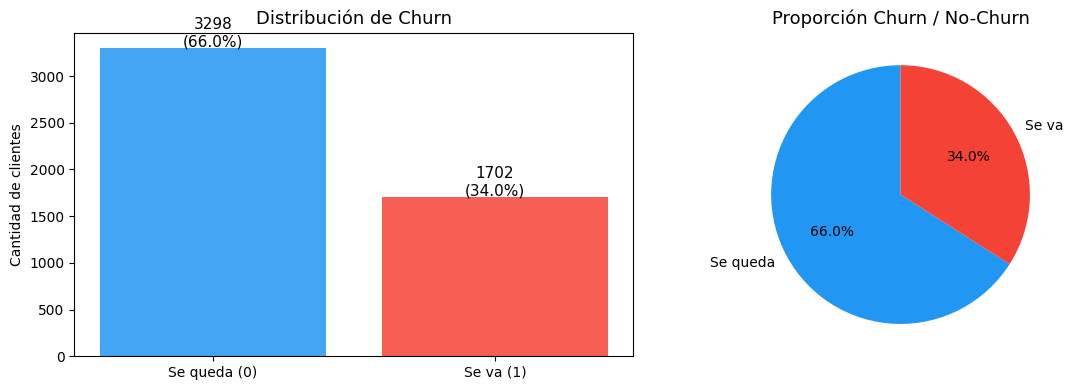


Dataset: 5,000 clientes
Churn = 0 (se queda): 3,298 (66.0%)
Churn = 1 (se va):    1,702 (34.0%)

Ratio de desbalance: 1.9:1

→ El dataset tiene desbalance moderado (≈34% churn).
  Esto implica que la ACCURACY no es la métrica ideal:
  un modelo que prediga siempre 0 tendría 66% de accuracy
  sin aprender nada útil. Usaremos F1-score y Recall como
  métricas principales de comparación.



In [5]:
# 2.1 Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Countplot
churn_counts = df['churn'].value_counts()
colors = ['#2196F3', '#F44336']
axes[0].bar(['Se queda (0)', 'Se va (1)'], churn_counts.values, color=colors, alpha=0.85)
axes[0].set_title('Distribución de Churn', fontsize=13)
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
 
# Pie
axes[1].pie(churn_counts.values, labels=['Se queda', 'Se va'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción Churn / No-Churn', fontsize=13)
 
plt.tight_layout()
plt.show()
 
print(f"""
Dataset: {len(df):,} clientes
Churn = 0 (se queda): {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)
Churn = 1 (se va):    {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)
 
Ratio de desbalance: {churn_counts[0]/churn_counts[1]:.1f}:1
 
→ El dataset tiene desbalance moderado (≈34% churn).
  Esto implica que la ACCURACY no es la métrica ideal:
  un modelo que prediga siempre 0 tendría 66% de accuracy
  sin aprender nada útil. Usaremos F1-score y Recall como
  métricas principales de comparación.
""")

## 3. Distribución de variables numéricas según churn

/tmp/ipykernel_91922/154761933.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Se queda (0)', 'Se va (1)'],
/tmp/ipykernel_91922/154761933.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Se queda (0)', 'Se va (1)'],
/tmp/ipykernel_91922/154761933.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Se queda (0)', 'Se va (1)'],
/tmp/ipykernel_91922/154761933.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

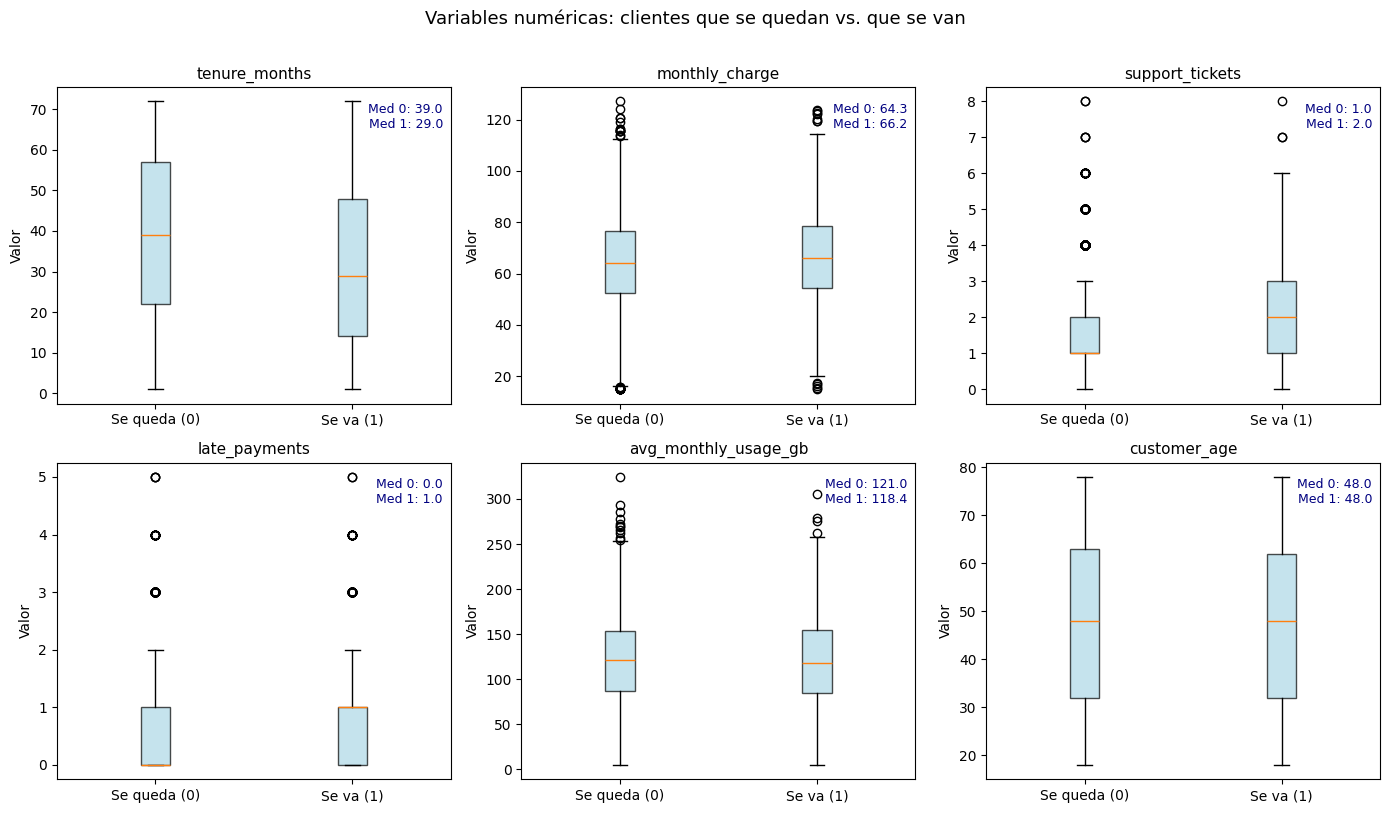


Hallazgos clave:
- tenure_months: los clientes que se van tienen MENOS antigüedad (mediana más baja)
  → confirma que clientes nuevos son más propensos al churn
- support_tickets: clientes con churn generan MÁS tickets de soporte
  → la mala experiencia de soporte es una señal de salida
- late_payments: más pagos tardíos en clientes con churn
  → señal de desenganche financiero o insatisfacción
- monthly_charge: distribución similar entre grupos, menor impacto directo
- customer_age y avg_monthly_usage_gb: diferencias pequeñas, menor poder predictivo esperado



In [6]:
# 3.1 Boxplots de variables numéricas vs churn
num_vars = ['tenure_months', 'monthly_charge', 'support_tickets',
            'late_payments', 'avg_monthly_usage_gb', 'customer_age']
 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
 
for i, var in enumerate(num_vars):
    data_0 = df[df['churn'] == 0][var]
    data_1 = df[df['churn'] == 1][var]
    axes[i].boxplot([data_0, data_1], labels=['Se queda (0)', 'Se va (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[i].set_title(var, fontsize=11)
    axes[i].set_ylabel('Valor')
 
    # Mediana de cada grupo
    m0, m1 = data_0.median(), data_1.median()
    axes[i].text(0.98, 0.95, f'Med 0: {m0:.1f}\nMed 1: {m1:.1f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color='navy')
 
plt.suptitle('Variables numéricas: clientes que se quedan vs. que se van', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
 
# Lectura crítica
print("""
Hallazgos clave:
- tenure_months: los clientes que se van tienen MENOS antigüedad (mediana más baja)
  → confirma que clientes nuevos son más propensos al churn
- support_tickets: clientes con churn generan MÁS tickets de soporte
  → la mala experiencia de soporte es una señal de salida
- late_payments: más pagos tardíos en clientes con churn
  → señal de desenganche financiero o insatisfacción
- monthly_charge: distribución similar entre grupos, menor impacto directo
- customer_age y avg_monthly_usage_gb: diferencias pequeñas, menor poder predictivo esperado
""")

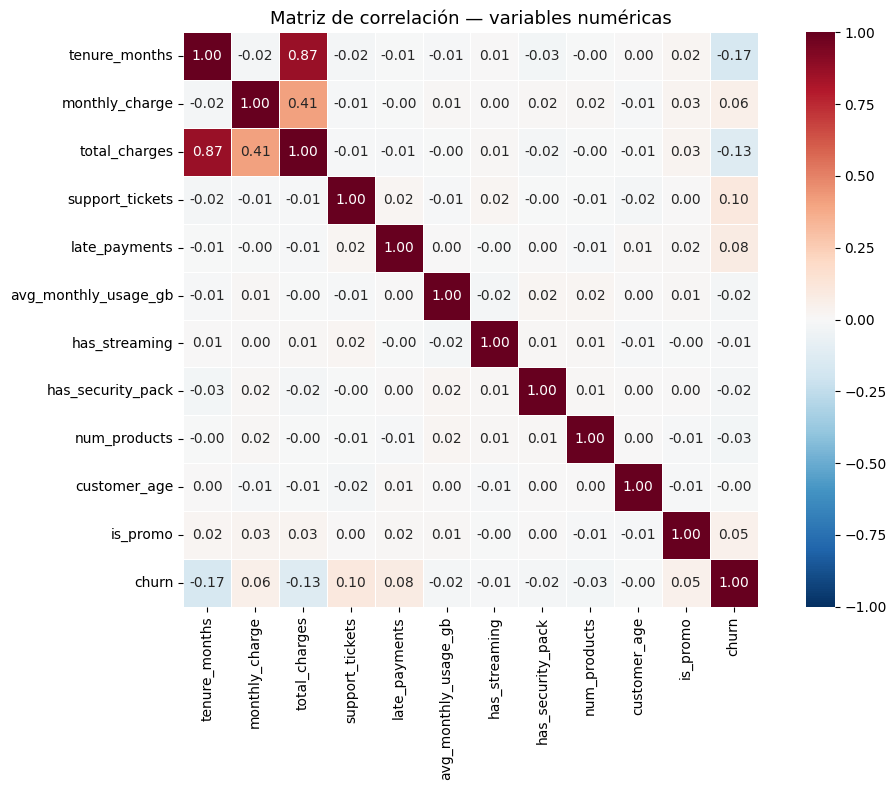


Correlaciones con churn (variable objetivo):

  ↓ tenure_months             r = -0.170
  ↓ total_charges             r = -0.125
  ↑ support_tickets           r = +0.102
  ↑ late_payments             r = +0.081
  ↑ monthly_charge            r = +0.062
  ↑ is_promo                  r = +0.051
  ↓ num_products              r = -0.027
  ↓ has_security_pack         r = -0.020
  ↓ avg_monthly_usage_gb      r = -0.018
  ↓ has_streaming             r = -0.008
  ↓ customer_age              r = -0.002

Nota: total_charges tiene alta correlación con tenure_months y monthly_charge
(es una variable derivada: total = tenure × monthly). Esto es colinealidad esperada
y el Pipeline con StandardScaler la maneja, aunque podría considerarse eliminarla.



In [7]:
# 3.2 Mapa de correlaciones
plt.figure(figsize=(11, 8))
num_cols = ['tenure_months', 'monthly_charge', 'total_charges', 'support_tickets',
            'late_payments', 'avg_monthly_usage_gb', 'has_streaming', 'has_security_pack',
            'num_products', 'customer_age', 'is_promo', 'churn']
 
corr = df[num_cols].corr()
mask = [[False]*len(num_cols) for _ in range(len(num_cols))]
 
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de correlación — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()
 
print("""
Correlaciones con churn (variable objetivo):
""")
corr_churn = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
for var, val in corr_churn.items():
    signo = '↑' if val > 0 else '↓'
    print(f"  {signo} {var:<25} r = {val:+.3f}")
 
print("""
Nota: total_charges tiene alta correlación con tenure_months y monthly_charge
(es una variable derivada: total = tenure × monthly). Esto es colinealidad esperada
y el Pipeline con StandardScaler la maneja, aunque podría considerarse eliminarla.
""")

## 4. Variables categóricas vs Churn

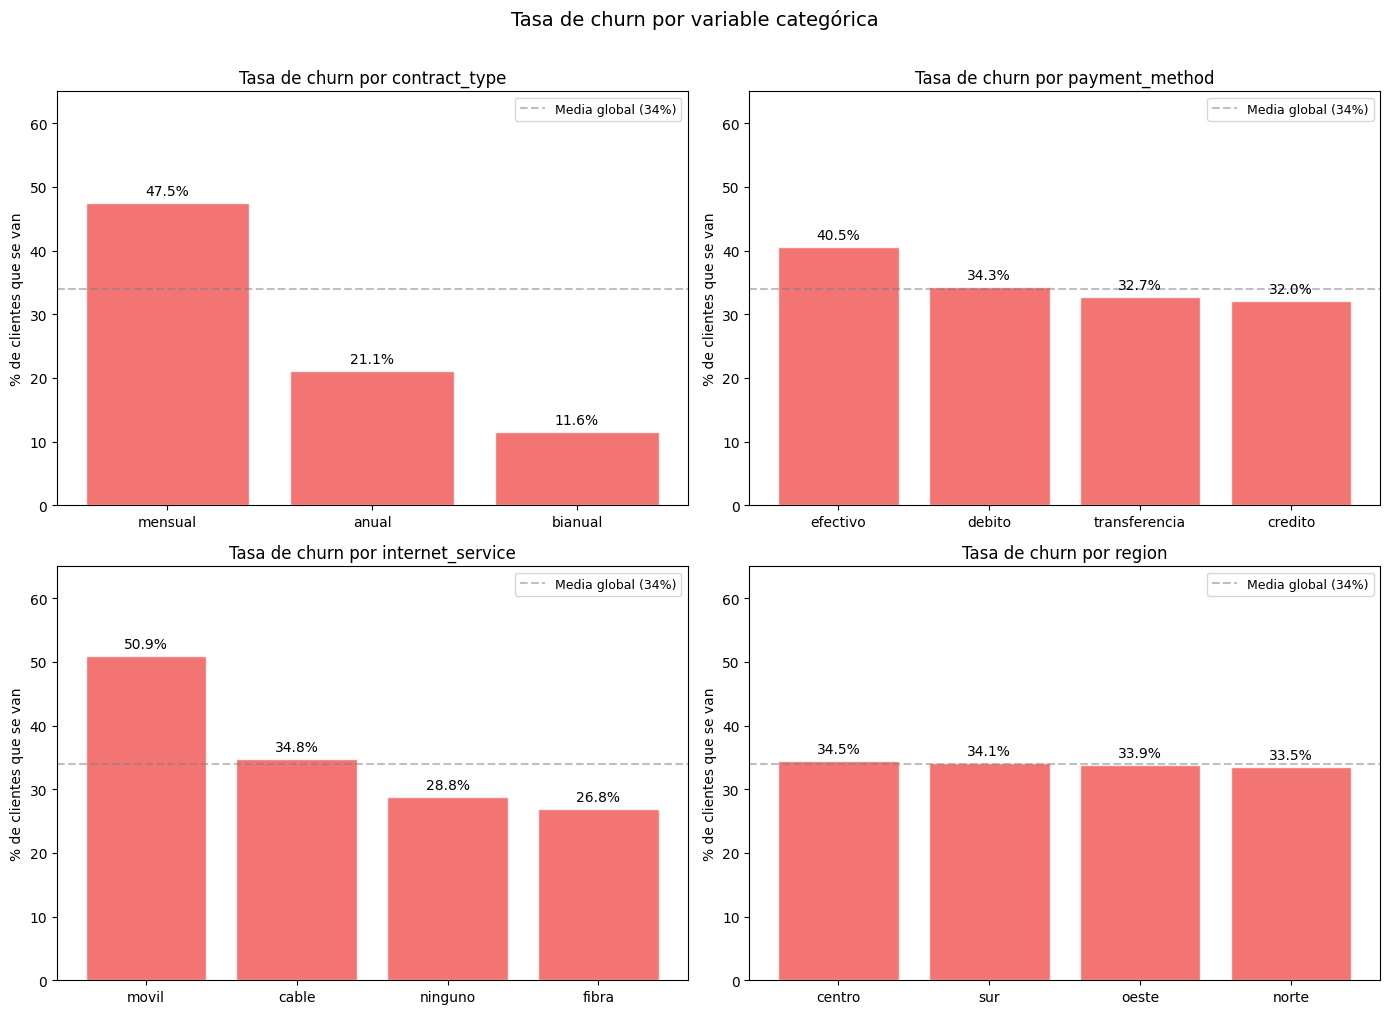

Hallazgos variables categoricas:
  contract_type:
    mensual         47.5% <- mayor riesgo
    anual           21.1%
    bianual         11.6%

  payment_method:
    efectivo        40.5% <- mayor riesgo
    debito          34.3%
    transferencia   32.7%
    credito         32.0%

  internet_service:
    movil           50.9% <- mayor riesgo
    cable           34.8%
    ninguno         28.8%
    fibra           26.8%

  region:
    centro          34.5% <- mayor riesgo
    sur             34.1%
    oeste           33.9%
    norte           33.5%



In [8]:
# 4.1 Tasa de churn por cada variable categórica
cat_vars = ['contract_type', 'payment_method', 'internet_service', 'region']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    churn_rate = df.groupby(var)['churn'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index, churn_rate.values * 100,
                       color='#EF5350', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Tasa de churn por {var}', fontsize=12)
    axes[i].set_ylabel('% de clientes que se van')
    axes[i].set_ylim(0, 65)
    axes[i].axhline(y=34, color='gray', linestyle='--', alpha=0.5, label='Media global (34%)')
    axes[i].legend(fontsize=9)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                     f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Tasa de churn por variable categórica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Hallazgos variables categoricas:')
for var in cat_vars:
    churn_rate = df.groupby(var)['churn'].mean().sort_values(ascending=False)
    print(f'  {var}:')
    for cat, rate in churn_rate.items():
        marker = ' <- mayor riesgo' if rate == churn_rate.max() else ''
        print(f'    {cat:<15} {rate*100:.1f}%{marker}')
    print()


## 5. Elección y justificación de métricas
 
En problemas de churn, **accuracy no es la métrica correcta**.
 
### ¿Por qué?
 
Con 34% de churn, un modelo "tonto" que prediga siempre "se queda"
tiene accuracy = 66% sin aprender nada útil.
 
### Lo que importa para AndesLink
 
AndesLink quiere activar campañas de retención. Para eso necesita
**identificar correctamente a los clientes que SE VAN** (clase 1).
 
- **Recall (clase 1)**: de todos los que realmente se van, ¿cuántos detectamos?
  Un recall bajo = clientes fugados que no pudimos retener.
 
- **Precision (clase 1)**: de los que predecimos que se van, ¿cuántos realmente se van?
  Una precision baja = recursos gastados en clientes que no iban a irse.
 
- **F1-score**: balance entre precision y recall. Es la métrica principal de comparación.
 
- **ROC-AUC**: mide la capacidad discriminativa del modelo en todos los umbrales.
  Útil para comparar modelos independientemente del umbral de decisión.
 
> El modelo final se seleccionará por **F1-score de la clase 1 (churn)**,
> no por accuracy global.

In [9]:
# --- LIMPIEZA DE DATOS ---

# 1. Eliminamos columnas no predictivas
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])
    print('Eliminada columna customer_id (no predictiva)')

# 2. Eliminamos duplicados
n_antes = len(df)
df = df.drop_duplicates()
print(f'Duplicados eliminados: {n_antes - len(df)}')

# 3. Verificamos nulos
nulos = df.isnull().sum().sum()
if nulos > 0:
    print(f'Nulos detectados: {nulos}. Aplicando imputacion por mediana...')
    cols_num = df.select_dtypes(include=['number']).columns.difference(['churn'])
    df[cols_num] = df[cols_num].fillna(df[cols_num].median())
else:
    print('Sin valores nulos. Dataset limpio.')

print(f'Dataset listo: {df.shape[0]:,} filas x {df.shape[1]} columnas')


Duplicados eliminados: 0
Sin valores nulos. Dataset limpio.
Dataset listo: 5,000 filas x 16 columnas


In [10]:
# Definimos X (características) y y (lo que queremos predecir)
X = df.drop('churn', axis=1)
y = df['churn']

# Dividimos: 80% para entrenar y 20% para testear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Datos de entrenamiento: (4000, 15)
Datos de prueba: (1000, 15)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
#Normalización (StandardScaler): Lo usamos porque variables como total_charges están en los miles, mientras que num_products va de 1 a 4. Si no normalizamos, el modelo va a pensar que el dinero es "más importante" solo porque el número es más grande.

#Encoding (OneHotEncoder): Es lo que soluciona el error que te dio antes (ValueError). Convierte las palabras en columnas de 0 y 1 para que el modelo pueda procesarlas.
# 1. Identificamos qué columnas son texto y cuáles números
# Según tu tabla, casi todo es número, pero detectamos strings. 
# Si tenés columnas como 'tipo_plan' o 'geografia' con texto, van acá:
# Identificamos columnas para el preprocesador
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
num_features = X_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorías a transformar: {cat_features}")
print(f"Números a escalar: {num_features}")

# Preprocesador — se usa dentro del loop de comparación
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

Categorías a transformar: ['contract_type', 'payment_method', 'internet_service', 'region']
Números a escalar: ['tenure_months', 'monthly_charge', 'total_charges', 'support_tickets', 'late_payments', 'avg_monthly_usage_gb', 'has_streaming', 'has_security_pack', 'num_products', 'customer_age', 'is_promo']


In [12]:
# Serializar el modelo ganador: Logistic Regression
from sklearn.linear_model import LogisticRegression
import os

modelo_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
modelo_final.fit(X_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(modelo_final, 'models/model_churn.pkl')
print("Modelo ganador serializado: Logistic Regression")
print("Guardado en models/model_churn.pkl")


Modelo ganador serializado: Logistic Regression
Guardado en models/model_churn.pkl


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, roc_auc_score, recall_score

modelos = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision_Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced'),
    "Random_Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

resultados = []
mlflow.end_run()  # cerrar cualquier run colgado antes de empezar

for nombre, mod in modelos.items():
    with mlflow.start_run(run_name=nombre):
        pipeline_temp = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', mod)
        ])
        pipeline_temp.fit(X_train, y_train)
        y_pred = pipeline_temp.predict(X_test)
        y_prob = pipeline_temp.predict_proba(X_test)[:, 1]

        acc     = pipeline_temp.score(X_test, y_test)
        f1      = f1_score(y_test, y_pred)
        recall  = recall_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        mlflow.log_metric("f1_churn", f1)
        mlflow.log_metric("recall_churn", recall)
        mlflow.log_metric("roc_auc", roc_auc)

        resultados.append({
            'Modelo': nombre,
            'Accuracy': round(acc, 4),
            'F1 (churn)': round(f1, 4),
            'Recall (churn)': round(recall, 4),
            'ROC-AUC': round(roc_auc, 4)
        })

        print(f"\n{nombre}")
        print(f"  Accuracy:       {acc:.4f}")
        print(f"  F1 (churn):     {f1:.4f}")
        print(f"  Recall (churn): {recall:.4f}")
        print(f"  ROC-AUC:        {roc_auc:.4f}")

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\n\n=== COMPARACIÓN FINAL ===")
print(df_resultados.to_string())
print("\n→ Modelo seleccionado: el de mayor F1 (churn)")
print(f"  Ganador: {df_resultados['F1 (churn)'].idxmax()}")


Logistic_Regression
  Accuracy:       0.7030
  F1 (churn):     0.6087
  Recall (churn): 0.7043
  ROC-AUC:        0.7675

Decision_Tree
  Accuracy:       0.6710
  F1 (churn):     0.5820
  Recall (churn): 0.6982
  ROC-AUC:        0.7293

Random_Forest
  Accuracy:       0.7120
  F1 (churn):     0.4440
  Recall (churn): 0.3506
  ROC-AUC:        0.7321


=== COMPARACIÓN FINAL ===
                     Accuracy  F1 (churn)  Recall (churn)  ROC-AUC
Modelo                                                            
Logistic_Regression     0.703      0.6087          0.7043   0.7675
Decision_Tree           0.671      0.5820          0.6982   0.7293
Random_Forest           0.712      0.4440          0.3506   0.7321

→ Modelo seleccionado: el de mayor F1 (churn)
  Ganador: Logistic_Regression


Modelo seleccionado: Regresión Logística con class_weight='balanced'

Criterio de selección: mayor F1-score (0.609) y Recall (0.704) en la clase churn,
y mayor ROC-AUC (0.768) entre los tres modelos evaluados.

Contra-intuitivamente, Random Forest tuvo el peor desempeño en F1 y Recall a pesar
de tener el mayor accuracy (0.712). Esto confirma por qué accuracy no es la métrica
correcta en este problema: RF aprendió a predecir bien la clase mayoritaria (se queda)
pero falló en detectar clientes en riesgo de fuga.

La Regresión Logística captura mejor la clase minoritaria gracias a su naturaleza
probabilística y al ajuste de class_weight='balanced', siendo la opción más adecuada
para el objetivo de negocio de AndesLink.
